In [1]:
from scdesigner.datasets import cite

exper = cite()
exper

AnnData object with n_obs × n_vars = 8617 × 1010
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.8', 'seurat_clusters', 'nCount_ADT', 'nFeature_ADT', 'ident', 'cell_type'

In [2]:
import numpy as np

keep = ["CD4",  "CD14", "CD19", "CD34", "CD3E", "CD8A", "ADT_CD4", "ADT_CD14", "ADT_CD19", "ADT_CD34", "ADT_CD3", "ADT_CD8"]
ix = np.where(np.isin(exper.var_names, keep))[0]
ix = np.concatenate([ix, np.arange(100)])
exper = exper[:, ix]
exper.obs["sample"] = range(len(exper))

In [3]:
from scdesigner.simulators import NegBinCopula

sim = NegBinCopula(
    mean_formula="~ cell_type", copula_formula="~ cell_type", top_k=25
)
sim.fit(exper)
samples = sim.sample()

Epoch 149/500, Loss: 1.3870, Val Loss: 1.3816


Estimating top-k copula correlation: 100%|██████████| 9/9 [00:00<00:00, 21.30it/s]


Using code from the accompanying `scdiagnostics` package, we can run UMAP on the PCA scores of $\log\left(1 + x\right)$ transformed data, as in the original vignette.

In [4]:
from scdiagnostics import compare_umap, overlay_expression
from sklearn.decomposition import TruncatedSVD
import altair
altair.renderers.enable('png')

def pca_project(X, n_comp=50):
    svd = TruncatedSVD(n_components=n_comp)
    return svd.fit_transform(np.log1p(X))

chart = compare_umap(exper, samples, pca_project, min_dist=0.1)

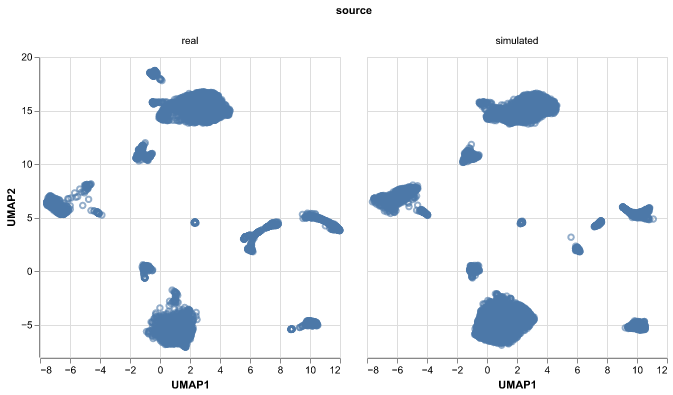

In [5]:
chart.show()

We can also overlay the original gene and protein expression values onto this UMAP by joining with the original experimental measurements, using `overlay_expression` from `scdiagnostics`.

Now we can join the data.

In [6]:
import pandas as pd

keep_x = pd.DataFrame(np.log1p(exper[:, keep].X.todense()), columns=keep)
umap_data = chart.transformed_data()
umap_data = umap_data.join(keep_x, on="sample", how="left", rsuffix="")

Finally, we can reshape and visualize.

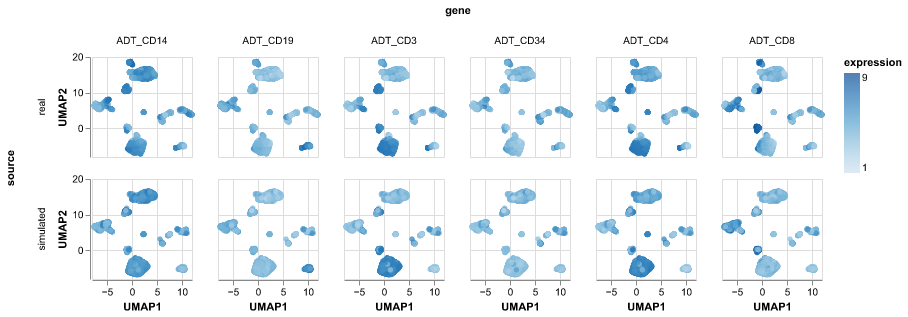

In [7]:
umap_pivot = pd.melt(
    umap_data,
    id_vars=["UMAP1", "UMAP2", "cell_type", "source"],
    value_vars=keep,
    var_name="gene",
    value_name="expression"
)

ix = umap_pivot["gene"].str.contains("ADT")
overlay_expression(umap_pivot[ix])

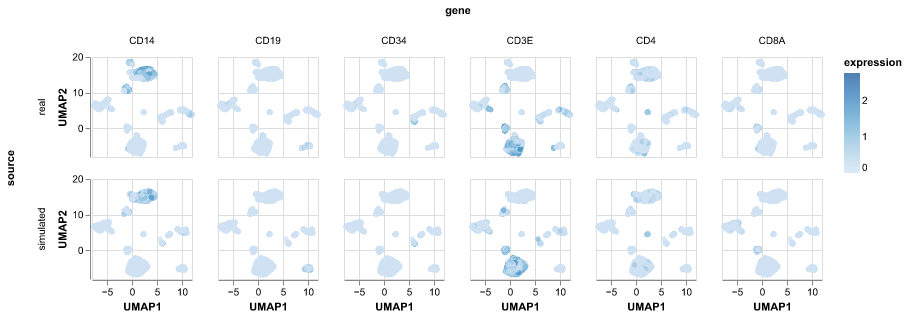

In [8]:
overlay_expression(umap_pivot[~ix])